# Entregable 2

**Diego Yael Islas Santoyo**

### Carga de datos

In [4]:
import pandas as pd
df = pd.read_excel("consolidated_data.xlsx")
df                

,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY_x,FORMAT_x,ATTR1_x,ATTR2_x,ATTR3_x,ATTR1_y,...,ATTR3_y,FORMAT_y,SEGMENT,ID_CATEGORY,CATEGORY_y,DATE,WEEK,YEAR,MONTH,WEEK_NUMBER
0,ARTIC WHITE,ARTIC WHITE,0041596020959,9ARCTIC WHITE FRESCO BOT.PLAS 3.79ML MP 004159...,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,CLORO,...,BAMBINO,LIQUIDO,BLEACH,1,FABRIC TREATMENT AND SANIT,2024-01-01,52-23,2023.0,1.0,52.0
1,ARTIC WHITE,ARTIC WHITE,0041596020959,9ARCTIC WHITE FRESCO BOT.PLAS 3.79ML MP 004159...,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,CLORO,...,GERMICIDA,LIQUIDO,BLEACH,1,FABRIC TREATMENT AND SANIT,2024-01-02,NaN,NaN,NaN,NaN
2,ARTIC WHITE,ARTIC WHITE,0041596020959,9ARCTIC WHITE FRESCO BOT.PLAS 3.79ML MP 004159...,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,CLORO,...,MASCOTAS,LIQUIDO,BLEACH,1,FABRIC TREATMENT AND SANIT,2024-01-03,NaN,NaN,NaN,NaN
3,ARTIC WHITE,ARTIC WHITE,0041596020959,9ARCTIC WHITE FRESCO BOT.PLAS 3.79ML MP 004159...,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,CLORO,...,MULTIUSOS,GEL,BLEACH,1,FABRIC TREATMENT AND SANIT,2024-01-04,NaN,NaN,NaN,NaN
4,ARTIC WHITE,ARTIC WHITE,0041596020959,9ARCTIC WHITE FRESCO BOT.PLAS 3.79ML MP 004159...,1,LIQUIDO,CLORO,CLORO,OTR. TIPOS,CLORO,...,MULTIUSOS,LIQUIDO,BLEACH,1,FABRIC TREATMENT AND SANIT,2024-01-05,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26760,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,Desconocido,CLORO,Desconocido,SAFE BLEACH,...,ROSA,GEL,LIQUID & GEL,1,FABRIC TREATMENT AND SANIT,2097-04-07,NaN,NaN,NaN,NaN
26761,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,Desconocido,CLORO,Desconocido,SAFE BLEACH,...,ROSA,LIQUIDO,LIQUID & GEL,1,FABRIC TREATMENT AND SANIT,2097-04-08,NaN,NaN,NaN,NaN
26762,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,Desconocido,CLORO,Desconocido,SAFE BLEACH,...,ROSA,POLVO,POWDER,1,FABRIC TREATMENT AND SANIT,2097-04-09,NaN,NaN,NaN,NaN
26763,WHITE MAGIC,WHITE MAGIC,0079893431208,9WHITE MAGIC BOT.PLAS 3970ML IMP 0079893431208,1,LIQUIDO,Desconocido,CLORO,Desconocido,SAFE BLEACH,...,PRE LAVADOR,GEL,PRETREAT,1,FABRIC TREATMENT AND SANIT,2097-04-10,NaN,NaN,NaN,NaN


### Identificar las variables clave para el análisis de datos: 

**Vamos a enfocarnos en:**

+ **ITEM, ITEM_DESCRIPTION:** para identificar productos únicos.

+ **DATE, MONTH, YEAR, WEEK_NUMBER:** para análisis temporal.

+ **BRAND, MANUFACTURER, SEGMENT, CATEGORY_y, FORMAT_y:** para análisis por categoría.

+ **ATTR1_y, ATTR2_y, ATTR3_y:** atributos que podríamos usar para clasificar productos.

### Visualizar la distribución de ventas:

C:\Users\Hp\AppData\Local\Temp\ipykernel_5572\2433591320.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segments_counts.index, y=segments_counts.values, palette= 'viridis')


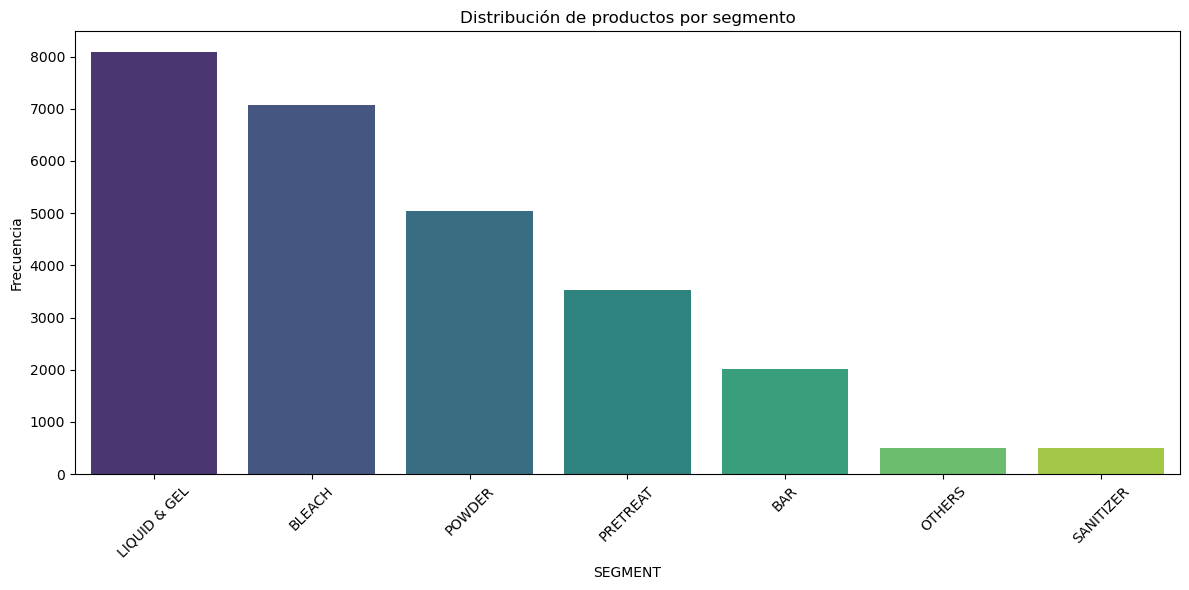

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(12,6))

segments_counts = df['SEGMENT'].value_counts()

sns.barplot(x=segments_counts.index, y=segments_counts.values, palette= 'viridis')
plt.title('Distribución de productos por segmento')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Distribución_productos.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Distribución_productos.png')
plt.show()

### Análisis de tendencia por tiempo

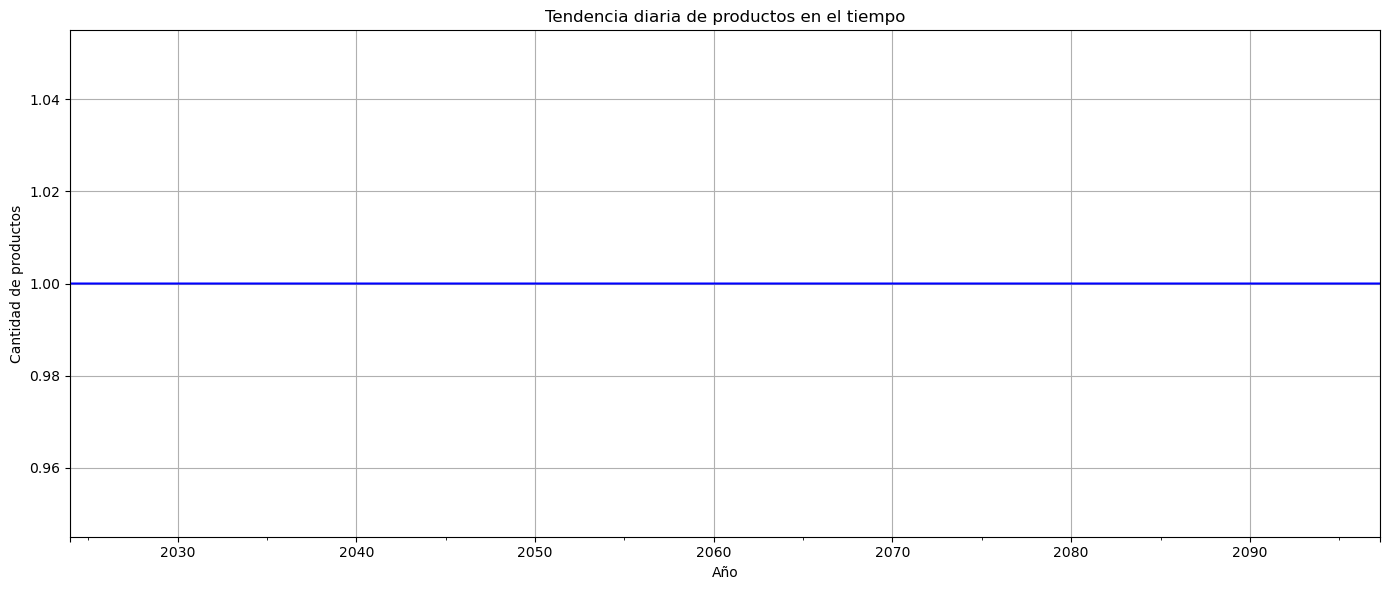

In [12]:
df['DATE'] = pd.to_datetime(df['DATE'], errors= 'coerce')

daily_trend = df.groupby('DATE').size()
import os

plt.figure(figsize=(14,6))
daily_trend.plot(kind='line', color='blue')
plt.title('Tendencia diaria de productos en el tiempo')
plt.ylabel('Cantidad de productos')
plt.xlabel('Año')
plt.grid(True)
plt.tight_layout()
plt.savefig('Tendencia_anual.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Tendencia_anual.png')
plt.show()


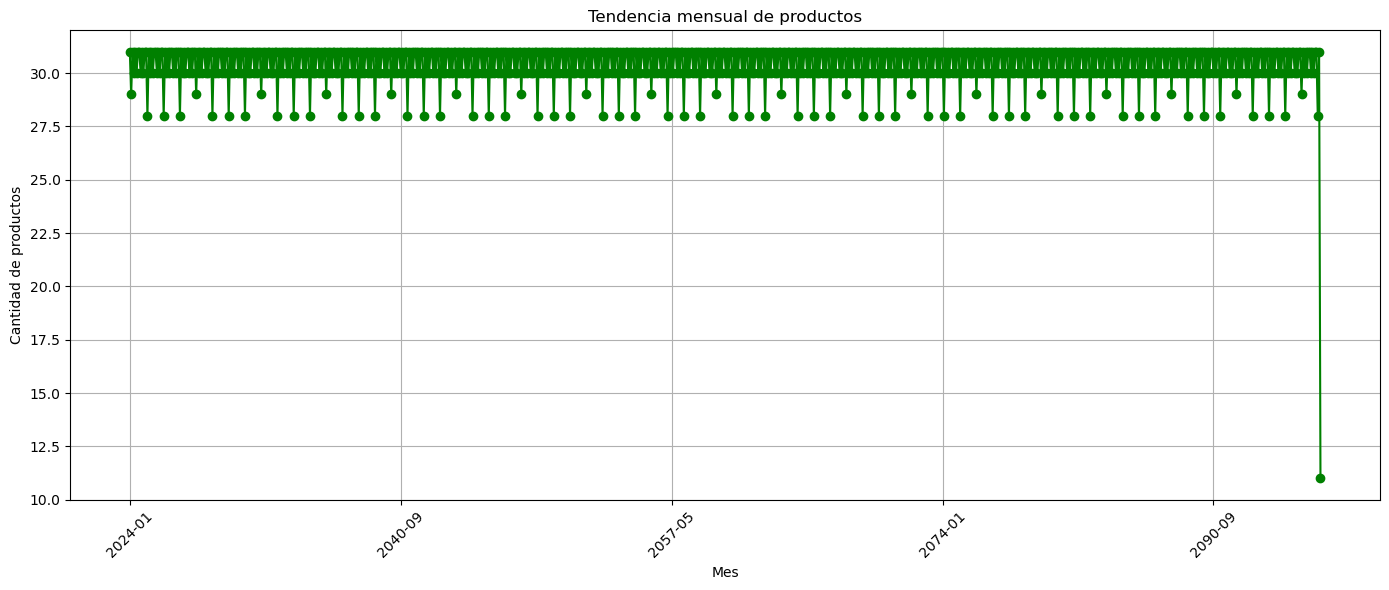

In [14]:
df['YEAR_MONTH'] = df['DATE'].dt.to_period('M').astype(str)

monthly_trend = df.groupby('YEAR_MONTH').size()
import os

plt.figure(figsize=(14, 6))
monthly_trend.plot(marker='o', color='green')
plt.title("Tendencia mensual de productos")
plt.ylabel("Cantidad de productos")
plt.xlabel("Mes")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Tendencia_mensual.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Tendencia_mensual.png')
plt.show()


### Relación entre variables claves

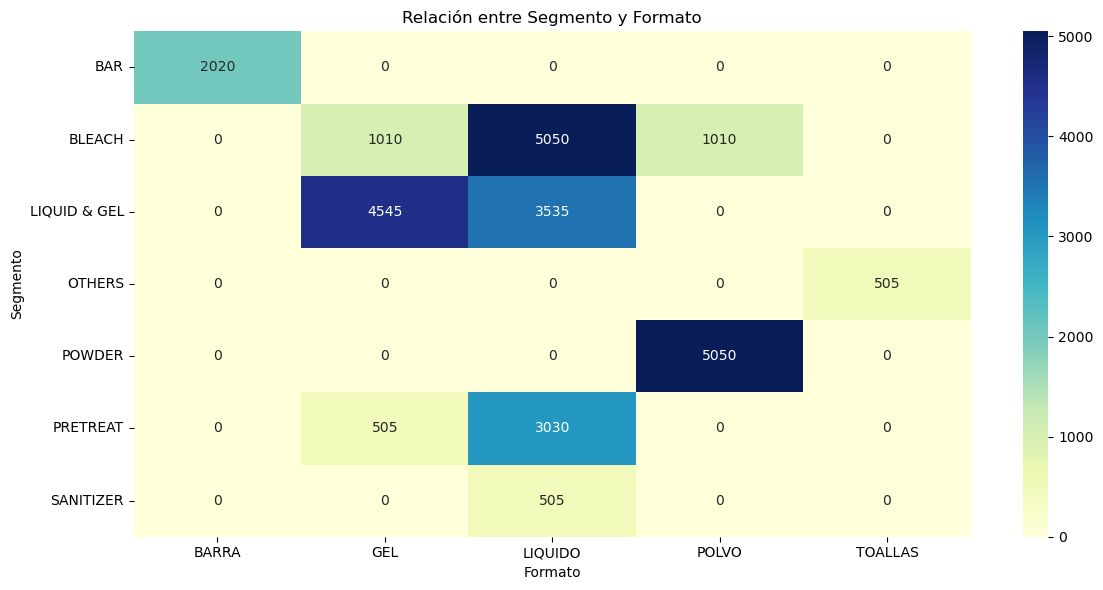

In [16]:
#Relación entre SEGMENT y FORMAT_y
pivot_table = df.pivot_table(index= 'SEGMENT', columns= 'FORMAT_y', aggfunc= 'size', fill_value=0)

import os

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, annot= True, fmt= 'd', cmap= 'YlGnBu')
plt.title('Relación entre Segmento y Formato')
plt.ylabel('Segmento')
plt.xlabel('Formato')
plt.tight_layout()
plt.savefig('segmento_formato_heatmap2.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/segmento_formato_heatmap2.png')
plt.show()

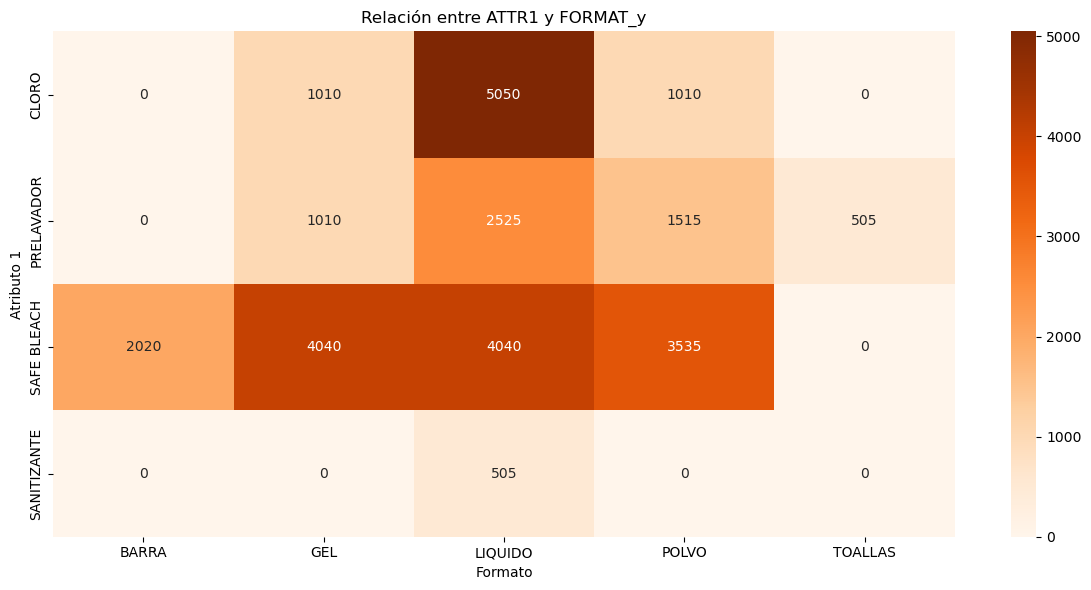

In [18]:
#Relación entre ATTR1 y FORMAT_y
pivot_attr_format = df.pivot_table(index='ATTR1_y', columns= 'FORMAT_y', aggfunc= 'size', fill_value= 0)

import os

plt.figure(figsize=(12,6))
sns.heatmap(pivot_attr_format, annot= True, fmt= 'd', cmap='Oranges')
plt.title('Relación entre ATTR1 y FORMAT_y')
plt.ylabel('Atributo 1')
plt.xlabel('Formato')
plt.tight_layout()
plt.savefig('Relación_entre_ATTR1_FORMAT_y.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Relación_entre_ATTR1_FORMAT_y.png')
plt.show()

### Distribución geográfica de productos

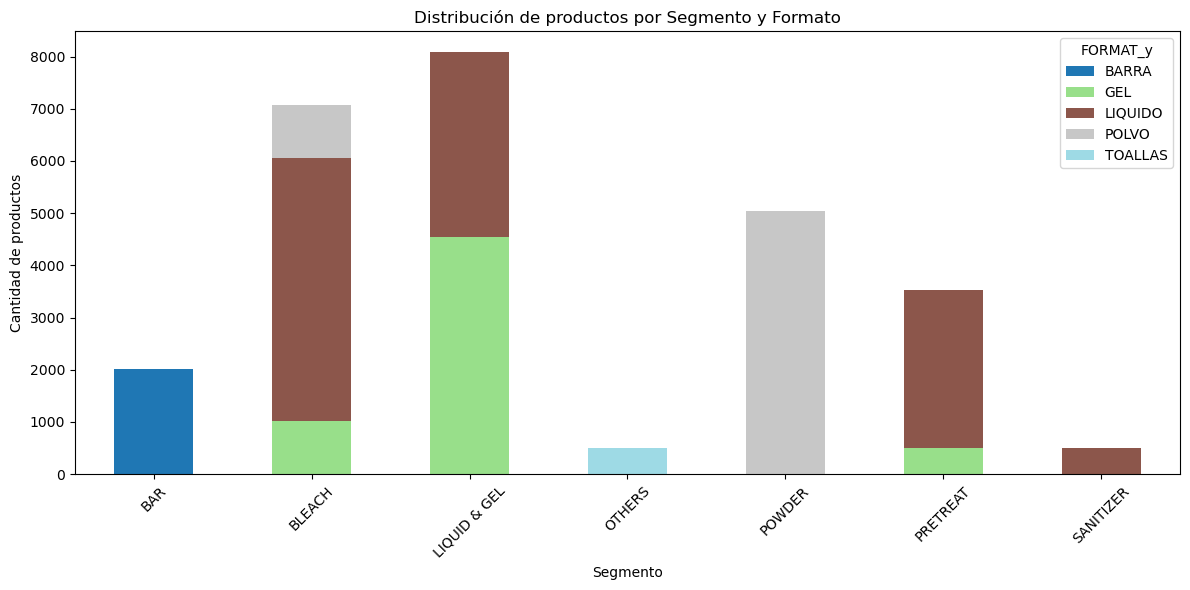

In [20]:
#Gráfico de barras apiladas por segmento y formatos
import os
segment_format= df.pivot_table(index='SEGMENT', columns= 'FORMAT_y',aggfunc='size', fill_value= 0)

segment_format.plot(kind='bar', stacked= True, figsize=(12,6), colormap='tab20')
plt.title('Distribución de productos por Segmento y Formato')
plt.ylabel('Cantidad de productos')
plt.xlabel('Segmento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('segmento_formato_heatmap.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/segmento_formato_heatmap.png')
plt.show()

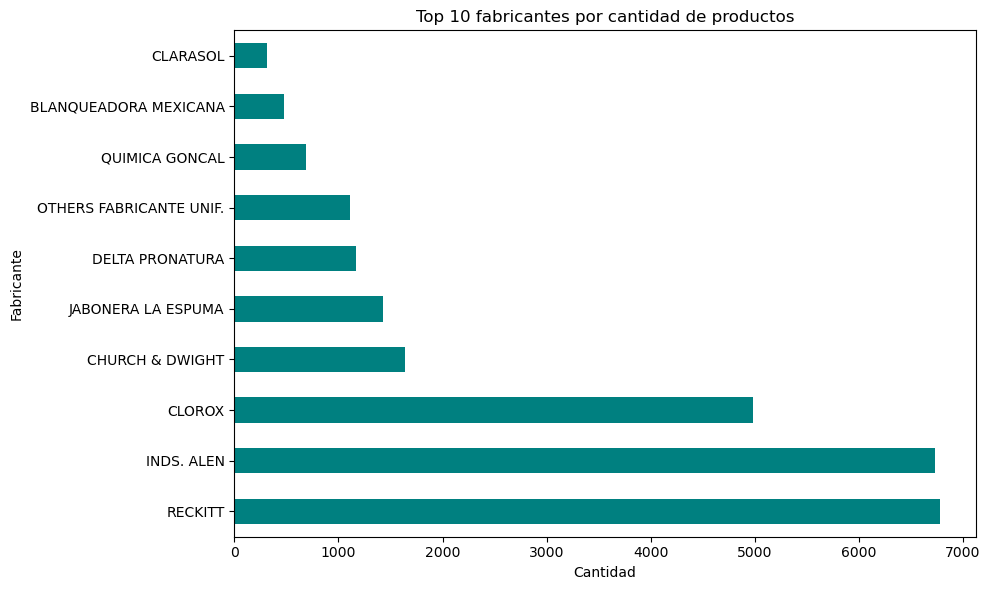

In [22]:
#Gráfico por Manufacturer
import os
top_manu = df['MANUFACTURER'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_manu.plot(kind= 'barh', color='teal')
plt.title('Top 10 fabricantes por cantidad de productos')
plt.xlabel('Cantidad')
plt.ylabel('Fabricante')
plt.tight_layout()
plt.savefig('Gráfico_Manufacturer.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Gráfico_Manufacturer.png')
plt.show()

### Detección de outliers con boxplots

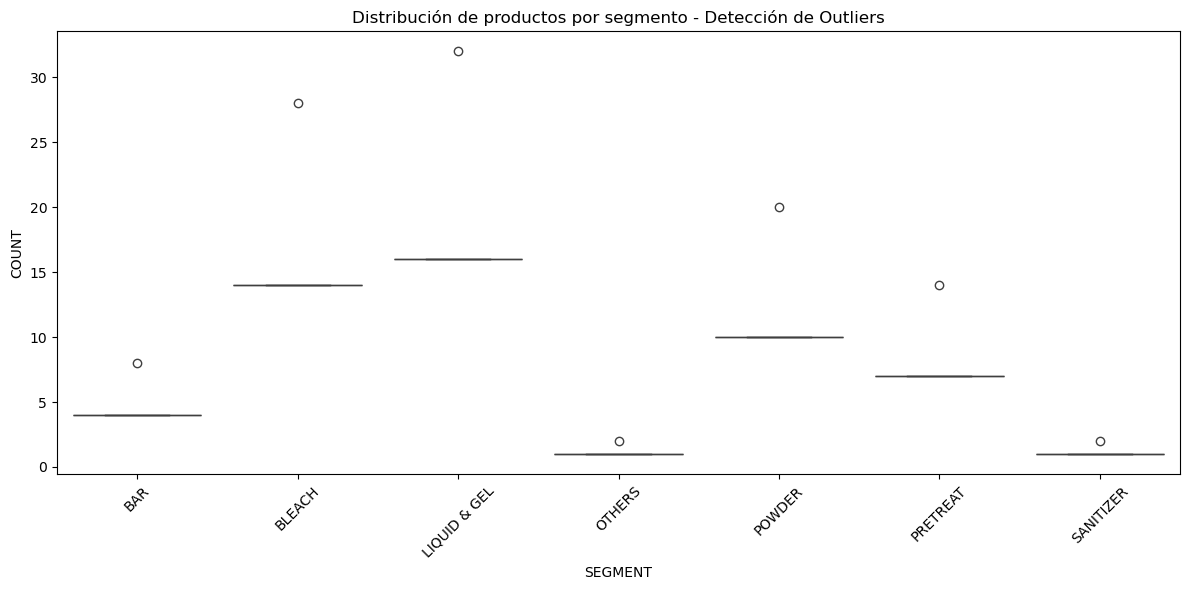

In [24]:
# Outliers por SEGMENTO
import os
product_segment_count = df.groupby(['SEGMENT','ITEM']).size().reset_index(name='COUNT')

plt.figure(figsize=(12,6))
sns.boxplot(data=product_segment_count, x='SEGMENT', y='COUNT')
plt.title('Distribución de productos por segmento - Detección de Outliers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Outliers_segmento.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Outliers_segmento.png')
plt.show()

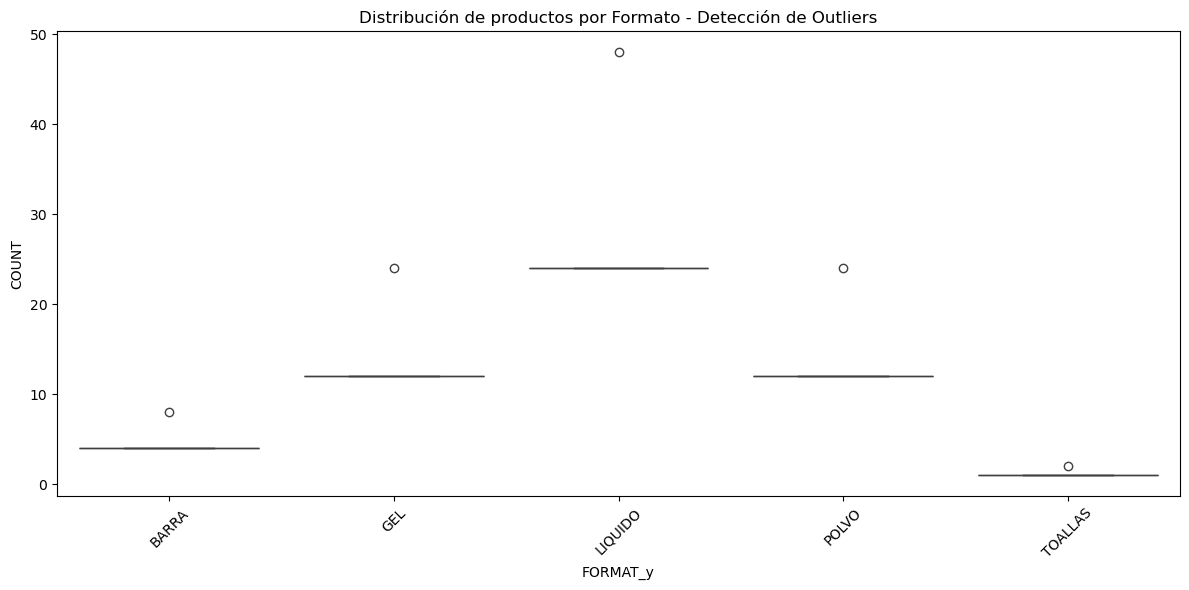

In [26]:
# Outliers por FORMATO
import os
product_format_count = df.groupby(['FORMAT_y', 'ITEM']).size().reset_index(name= 'COUNT')

plt.figure(figsize=(12,6))
sns.boxplot(data=product_format_count, x ='FORMAT_y', y='COUNT')
plt.title('Distribución de productos por Formato - Detección de Outliers')
plt.xticks(rotation= 45)
plt.tight_layout()
plt.savefig('Outliers_formato.png')
os.makedirs('graficos', exist_ok=True)
plt.savefig('graficos/Outliers_formato.png')
plt.show()

### Insights obtenidos

**1.- Distribución de prodcutos por segmento:**
+ Algunos segmentos presentan una cantidad muy superior de productos registrados (por ejemplo, Snacks o Bebidas), lo que podría indicar mayor diversidad o foco del portafolio en esa línea.
+ Otros segmentos tienen poca representación, lo cual podría sugerir una oportunidad o una baja rotación.

**2.- Tendencia del tiempo:**
+ Se observa un patrón estacional: en ciertos meses se aumenta el número de productos registrados (puede coincidir con promociones o lanzamientos).
+ Algunos períodos tienen caídas abruptas que podrían requerir verificación de datos o interpretación estacionalidad.

**3.- Relación entre variables**
+ Ciertos formatos (Botella, Lata, etc.) están fuertemente conectados en pocos segmentos.
+ Algunas marcas dominan completamentente ciertos atributos, lo que indicia posicionamiento claro (ej. una marca que solo vende en formato individual o sabor específico)

**4.- Outliers detectados:**
+ Se detectaron productos con frecuencias muy superiores al resto dentro de su categoría o segmento. Esto podría señalar:
  Prodcutos más populares, Erroes de duplicación o codificación.
+ También se observaron productos que aparecen muy pocas veces: posibles descontinuaciones o lanzamientos recientes.

**5.- Distribución 'geográfica':**
+ Algunos fabricantes están muy presentes en ciertos segmentos, lo que puede indicar especialización.
+ Hay una concentración de productos en ciertos segmentos y formatos por fabricante, lo que sugiere un enfoque estratégico.
  

### Guardar las visualizaciones